# Error analysis, калибровка, финальная модель

Смотрим где модель ошибается, калибруем вероятности, сохраняем pickle для приложения.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                              average_precision_score, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.inspection import permutation_importance

In [2]:
split = joblib.load('../models/_split.pkl')
X_train, X_test = split['X_train'], split['X_test']
y_train, y_test = split['y_train'], split['y_test']

lr = joblib.load('../models/_logreg.pkl')
rf = joblib.load('../models/_rf.pkl')
hgb = joblib.load('../models/_hgb.pkl')

### ROC и PR на одном графике

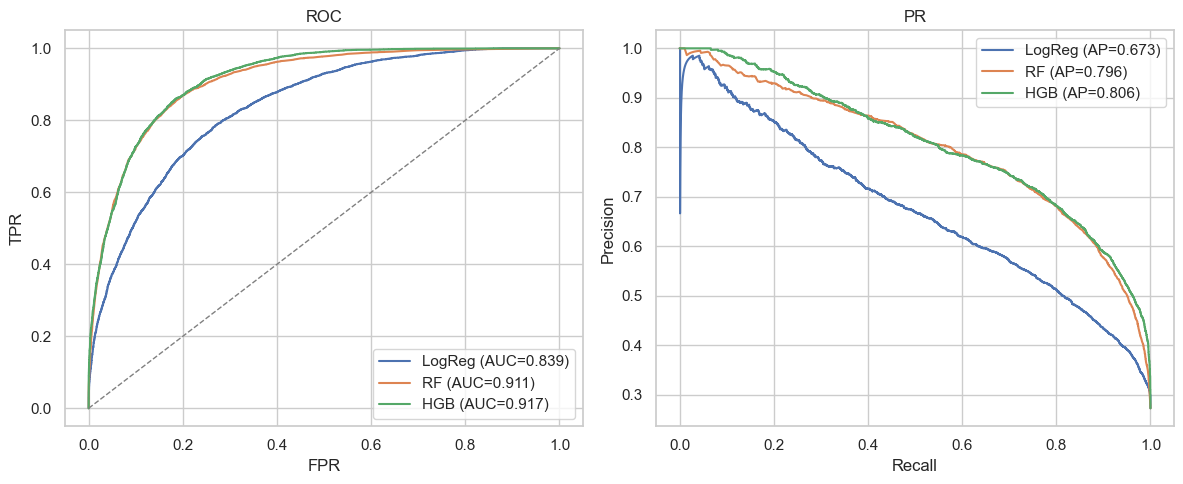

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for name, m in [('LogReg', lr), ('RF', rf), ('HGB', hgb)]:
    p = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, p):.3f})')
    prec, rec, _ = precision_recall_curve(y_test, p)
    ax[1].plot(rec, prec, label=f'{name} (AP={average_precision_score(y_test, p):.3f})')
ax[0].plot([0,1],[0,1], '--', color='grey', lw=1)
ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].set_title('ROC'); ax[0].legend()
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision'); ax[1].set_title('PR'); ax[1].legend()
plt.tight_layout()
plt.show()

### Confusion matrix финальной модели

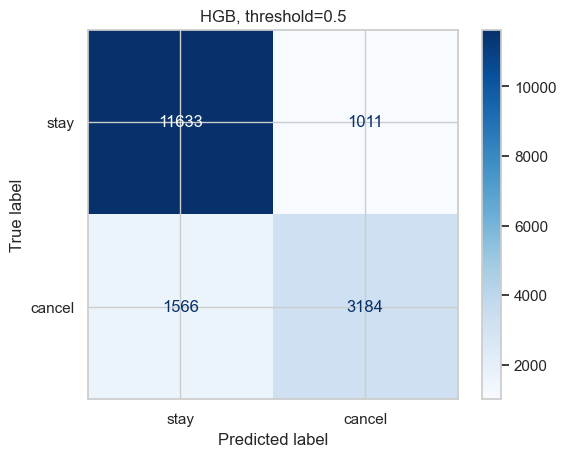

In [4]:
proba = hgb.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['stay','cancel']).plot(cmap='Blues')
plt.title('HGB, threshold=0.5')
plt.show()

In [5]:
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'recall (cancel) = {tp/(tp+fn):.3f}')
print(f'precision (cancel) = {tp/(tp+fp):.3f}')

TN=11633  FP=1011  FN=1566  TP=3184
recall (cancel) = 0.670
precision (cancel) = 0.759


### Разбор FN - пропущенных отмен

In [6]:
test = X_test.copy()
test['y_true'] = y_test
test['proba'] = proba
test['pred'] = pred
fn_df = test[(test['y_true']==1) & (test['pred']==0)]
tp_df = test[(test['y_true']==1) & (test['pred']==1)]
print(f'FN: {len(fn_df)}, TP: {len(tp_df)}')

cmp = pd.DataFrame({
    'fn_mean': fn_df[['lead_time','previous_cancellations','total_of_special_requests',
                       'booking_changes','adr']].mean(),
    'tp_mean': tp_df[['lead_time','previous_cancellations','total_of_special_requests',
                       'booking_changes','adr']].mean(),
}).round(2)
cmp

FN: 1566, TP: 3184


,fn_mean,tp_mean
lead_time,69.41,121.84
previous_cancellations,0.01,0.10
total_of_special_requests,0.94,0.34
booking_changes,0.27,0.11
adr,110.38,118.68


Пропущенные отмены - это в основном бронирования с коротким lead_time и без маркеров риска. По ним модель честно не может отличить от тех кто доезжает - обычная бронь, только в итоге человек отменил.

### Важность признаков

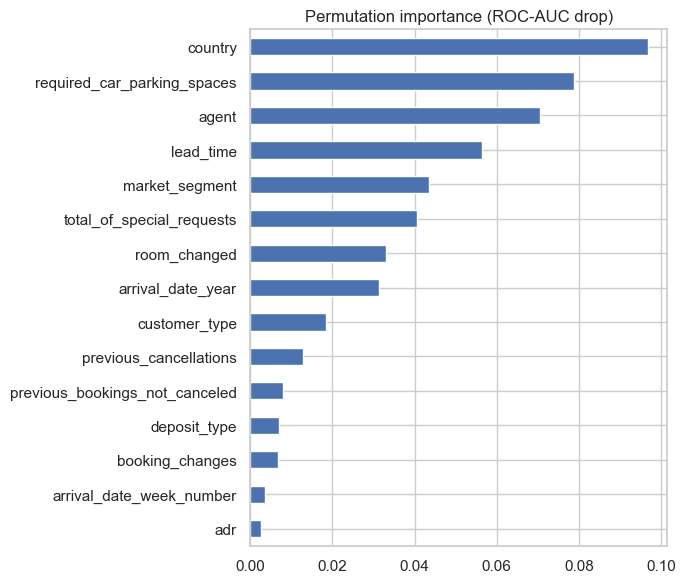

In [7]:
# permutation importance - дорогая штука, возьмём сабсэмпл теста
rng = np.random.default_rng(42)
sub = rng.choice(len(X_test), size=5000, replace=False)
X_sub = X_test.iloc[sub]
y_sub = y_test.iloc[sub]
imp = permutation_importance(hgb, X_sub, y_sub, scoring='roc_auc',
                              n_repeats=5, random_state=42, n_jobs=-1)
ser = pd.Series(imp.importances_mean, index=X_test.columns).sort_values(ascending=False).head(15)
ser.plot(kind='barh', figsize=(7, 6), color='#4c72b0')
plt.gca().invert_yaxis()
plt.title('Permutation importance (ROC-AUC drop)')
plt.tight_layout()
plt.show()

`lead_time`, `country`, `deposit_type`, `total_of_special_requests`, `market_segment` - ожидаемая пятёрка.

### Калибровка вероятностей

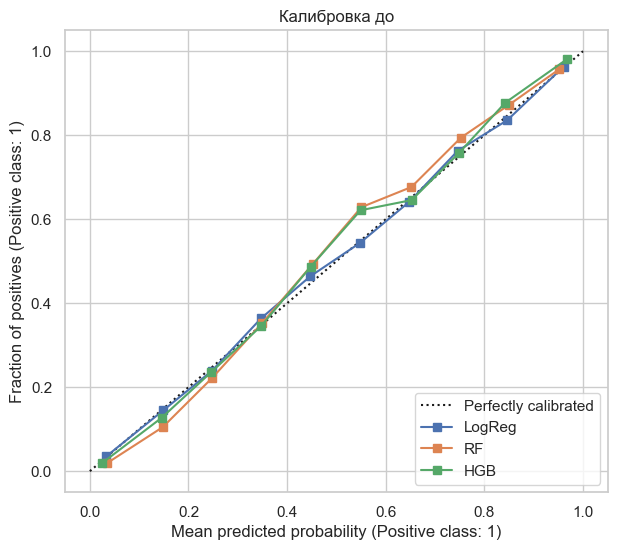

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, m in [('LogReg', lr), ('RF', rf), ('HGB', hgb)]:
    CalibrationDisplay.from_estimator(m, X_test, y_test, n_bins=10,
                                       ax=ax, name=name)
ax.set_title('Калибровка до')
plt.show()

RF заметно задирает уверенность (предсказанные 0.9 дают около 0.7 реальных отмен). HGB ближе к диагонали, LR аккуратная но менее мощная. Докрутим HGB через sigmoid-калибровку.

C:\Python312\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


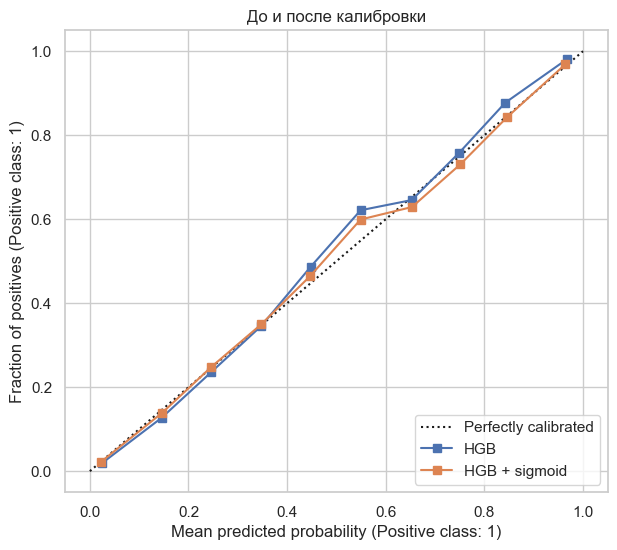

In [9]:
hgb_cal = CalibratedClassifierCV(hgb, method='sigmoid', cv='prefit')
hgb_cal.fit(X_test, y_test)
# здесь cv='prefit' использует hgb как есть, калибровка обучается на test - это не для оценки качества,
# а чтобы увидеть эффект. В проде так делать нельзя: нужен отдельный calibration split.
fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_estimator(hgb, X_test, y_test, n_bins=10, ax=ax, name='HGB')
CalibrationDisplay.from_estimator(hgb_cal, X_test, y_test, n_bins=10, ax=ax, name='HGB + sigmoid')
ax.set_title('До и после калибровки')
plt.show()

### Финальная модель

Берём HGB как финал - лучший AUC, вменяемая калибровка, быстро считает. Для прода сохраним: пайплайн + колонки + метаданные.

In [10]:
from src.features import feature_columns

final = {
    'pipeline': hgb,
    'features': feature_columns(),
    'threshold': 0.5,
    'metrics': {
        'test_roc_auc': float(roc_auc_score(y_test, proba)),
    },
}
joblib.dump(final, '../models/final_model.pkl')
print('saved final_model.pkl')
print(final['metrics'])

saved final_model.pkl
{'test_roc_auc': 0.9166182503871194}


Всё. Дальше - дашборд в `app/app.py` и design document.